In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python

import io # Input/Output Module
import os # OS interfaces
import cv2 # OpenCV package
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

from urllib import request # module for opening HTTP requests
from matplotlib import pyplot as plt # Plotting library


<div style="width:100%; height:140px">
    <img src="https://www.kuleuven.be/internationaal/thinktank/fotos-en-logos/ku-leuven-logo.png/image_preview" width = auto, heigh = 200px align=left>
</div>


KUL H02A5a Computer Vision: Group Assignment 1
---------------------------------------------------------------
<div style="height:50px"></div>

<span style="color:red">**TODO**: Add your names below.</span>

<span style="color:red">**TODO**: Change the notebook name by replacing the X with your actual group number.</span>

Student names: <span style="color:red">Hung Sum So(r0727162), name2, ...</span>.

The goal of this assignment is to explore more advanced techniques for constructing features that better describe objects of interest and to perform face recognition using these features. This assignment will be delivered in groups of 5 (either composed by you or randomly assigned by your TA's).

---------------------------------------------------------------
This notebook is structured as follows:

0. Data loading & Preprocessing
1. Feature Representations
2. Evaluation Metrics 
3. Classifiers
4. Experiments
5. Publishing best results
6. Discussion

Make sure that your notebook is **self-contained** and **fully documented**. Provide strong arguments for the design choices that you made and what insights you got from your experiments. Make use of the *Group assignment 1* forum/discussion board on Toledo if you have any questions.

Good luck! 


<div class="alert alert-block alert-info">
<b>NOTE:</b> This notebook is just a example/template, feel free to adjust in any way you please! Just keep things organised and document accordingly!
</div>

<div class="alert alert-block alert-info">
<b>NOTE:</b> Clearly indicate the improvements that you make!!! You can for instance use titles like: <i>3.1. Improvement: Non-linear SVM with RBF Kernel.<i>
</div>
    
---------------------------------------------------------------
# 0. Data loading & Preprocessing

## 0.1. Loading data
The training set is many times smaller than the test set and this might strike you as odd, however, this is close to a real world scenario where your system might be put through daily use! In this session we will try to do the best we can with the data that we've got! 

In [2]:
# Input data files are available in the read-only "../input/" directory

train = pd.read_csv(
    './kaggle/input/kul-computer-vision-ga-1-2025/train_set.csv', index_col = 0)
train.index = train.index.rename('id')

test = pd.read_csv(
    './kaggle/input/kul-computer-vision-ga-1-2025/test_set.csv', index_col = 0)
test.index = test.index.rename('id')

# read the images as numpy arrays and store in "img" column
train['img'] = [cv2.cvtColor(np.load('./kaggle/input/kul-computer-vision-ga-1-2025/train/train_{}.npy'.format(index), allow_pickle=False), cv2.COLOR_BGR2RGB) 
                for index, row in train.iterrows()]

test['img'] = [cv2.cvtColor(np.load('./kaggle/input/kul-computer-vision-ga-1-2025/test/test_{}.npy'.format(index), allow_pickle=False), cv2.COLOR_BGR2RGB) 
                for index, row in test.iterrows()]

train_size, test_size = len(train),len(test)

"The training set contains {} examples, the test set contains {} examples.".format(train_size, test_size)

'The training set contains 80 examples, the test set contains 1816 examples.'

In [3]:
# Check source photos
# from matplotlib import pyplot as plt
# for i in range(100):
#     plt.imshow(train['img'].iloc[i])
#     plt.show()

*Note: this dataset is a subset of the* [*VGG face dataset*](https://www.robots.ox.ac.uk/~vgg/data/vgg_face/).

## 0.2. A first look
Let's have a look at the data columns and class distribution.

In [4]:
# The training set contains an identifier, name, image information and class label
train.head(1)

,name,class,img
id,,,
0,Mila_Kunis,2,"[[[50, 31, 25], [49, 30, 24], [49, 30, 24], [4..."


In [5]:
# The test set only contains an identifier and corresponding image information.

test.head(1)

,img
id,
0,"[[[209, 210, 205], [208, 209, 204], [208, 209,..."


In [6]:
# The class distribution in the training set:
train.groupby('name').agg({'img':'count', 'class': 'max'})

,img,class
name,,
Jesse_Eisenberg,30,1
Michael_Cera,10,0
Mila_Kunis,30,2
Sarah_Hyland,10,0


Note that **Jesse is assigned the classification label 1**, and **Mila is assigned the classification label 2**. The dataset also contains 20 images of **look alikes (assigned classification label 0)** and the raw images. 

## 0.3. Preprocess data
### 0.3.1 Example: HAAR face detector
In this example we use the [HAAR feature based cascade classifiers](https://opencv-python-tutroals.readthedocs.io/en/latest/py_tutorials/py_objdetect/py_face_detection/py_face_detection.html) to detect faces, then the faces are resized so that they all have the same shape. If there are multiple faces in an image, we only take the first one. 

<div class="alert alert-block alert-info"> <b>NOTE:</b> You can write temporary files to <code>/kaggle/temp/</code> or <code>../../tmp</code>, but they won't be saved outside of the current session
</div>


In [7]:
# class HAARPreprocessor():
#     """Preprocessing pipeline built around HAAR feature based cascade classifiers. """
    
#     def __init__(self, path, face_size):
#         self.face_size = face_size
#         file_path = os.path.join(path, "haarcascade_frontalface_default.xml")
#         if not os.path.exists(file_path): 
#             if not os.path.exists(path):
#                 os.mkdir(path)
#             self.download_model(file_path)
        
#         self.classifier = cv2.CascadeClassifier(file_path)
  
#     def download_model(self, path):
#         url = "https://raw.githubusercontent.com/opencv/opencv/master/data/"\
#             "haarcascades/haarcascade_frontalface_default.xml"
        
#         with request.urlopen(url) as r, open(path, 'wb') as f:
#             f.write(r.read())
            
#     def detect_faces(self, img):
#         """Detect all faces in an image."""
        
#         img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
#         return self.classifier.detectMultiScale(
#             img_gray,
#             scaleFactor=1.1,       # Lower scale factor for more thorough scanning
#             minNeighbors=6,        # INCREASED from 5 to 6 to filter out false positives
#             minSize=(50, 50),      # INCREASED to ignore tiny faces in the background
#             flags=cv2.CASCADE_SCALE_IMAGE
#         )
    
#     def preprocess(self, data_row):
#         img = data_row['img']
#         faces = self.detect_faces(img)
        
#         # Fallback: If no faces are found, return the resized original
#         if len(faces) == 0:
#             return cv2.resize(img, self.face_size, interpolation=cv2.INTER_AREA).astype(np.uint8)
        
#         # --- THE NEW FIX: Center-Weighted Scoring ---
#         img_h, img_w = img.shape[:2]
#         img_center_x, img_center_y = img_w / 2, img_h / 2
        
#         best_face = None
#         highest_score = -1
        
#         for (x, y, w, h) in faces:
#             # 1. Calculate Face Area
#             area = w * h
            
#             # 2. Calculate Face Distance to the exact center of the image
#             face_center_x = x + (w / 2)
#             face_center_y = y + (h / 2)
            
#             distance_to_center = math.sqrt(
#                 (face_center_x - img_center_x)**2 + 
#                 (face_center_y - img_center_y)**2
#             )
            
#             # 3. Calculate Score (Area divided by distance)
#             # We add 1 to the distance to prevent dividing by zero if it's perfectly centered
#             score = area / (distance_to_center + 1)
            
#             if score > highest_score:
#                 highest_score = score
#                 best_face = (x, y, w, h)
                
#         # Extract the winning face
#         x, y, w, h = best_face
#         best_face_crop = img[y:y+h, x:x+w]
        
#         return cv2.resize(best_face_crop, self.face_size, interpolation=cv2.INTER_AREA).astype(np.uint8)

#     def __call__(self, data):
#         return np.stack([self.preprocess(row) for _, row in data.iterrows()])

In [8]:
import matplotlib.pyplot as plt
import numpy as np
import math
import random

def visualize_image_grid(images, labels=None, max_images=25, columns=5, random_sample=False):
    """
    Plots a grid of images. 
    Prevents notebook crashing by limiting the output to 'max_images'.
    """
    # 1. Decide which images to show
    total_images = len(images)
    display_count = min(total_images, max_images)
    
    if random_sample:
        # Pick random indices if we want a shuffled view
        indices = random.sample(range(total_images), display_count)
    else:
        # Otherwise, just take the first 'display_count' images
        indices = range(display_count)
        
    # 2. Calculate grid size
    rows = math.ceil(display_count / columns)
    
    # 3. Setup the matplotlib figure
    # 3 inches per column, 3.5 inches per row looks clean
    plt.figure(figsize=(3 * columns, 3.5 * rows))
    
    for plot_idx, img_idx in enumerate(indices):
        plt.subplot(rows, columns, plot_idx + 1)
        
        img = images[img_idx]
        
        # Handle Grayscale vs RGB display safely
        if len(img.shape) == 2:
            plt.imshow(img, cmap='gray')
        else:
            # Note: OpenCV loads images in BGR format. 
            # If your images look like "Smurfs" (blue skin), uncomment the line below:
            # img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            plt.imshow(img)
            
        # Add titles if labels were provided
        if labels is not None:
            # Map the numeric labels back to readable names if you like
            class_names = {0: 'Lookalike', 1: 'Jesse', 2: 'Mila'}
            label_name = class_names.get(labels[img_idx], labels[img_idx])
            plt.title(f"Label: {label_name}", fontsize=10)
            
        plt.axis('off') # Hide the axis ticks for a cleaner look
        
    plt.tight_layout()
    plt.show()

In [9]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# MediaPipePreprocessor  
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
import mediapipe as mp
import urllib.request, os, cv2, numpy as np

# ── Hard-coded outlier indices (0-based row position in train/test) ──
# Run your plot cells first, identify bad crops visually, then list their
# DataFrame positional indices here. These will be REPLACED with the
# original image resized — no face crop attempted.
TRAIN_OUTLIER_INDICES = set()   # e.g. {18, 20} after you identify them
TEST_OUTLIER_INDICES  = set()

class MediaPipePreprocessor():
    """V4: tighter crop, smarter fallback, outlier bypass."""

    CONF_THRESHOLD_HIGH = 0.5   # preferred detections
    CONF_THRESHOLD_LOW  = 0.15  # lenient second pass
    PAD_RATIO = 0.25            # slightly looser than V3's 0.2

    def __init__(self, face_size=(128, 128)):
        self.face_size = face_size
        self.stats = {'detected': 0, 'failed': 0, 'aligned': 0, 'outlier': 0}
        self.confidence_log = {}
        self.quality_flags  = {}

        model_path = './blaze_face_short_range.tflite'
        if not os.path.exists(model_path):
            print("📥 Downloading MediaPipe model...")
            urllib.request.urlretrieve(
                "https://storage.googleapis.com/mediapipe-models/face_detector/"
                "blaze_face_short_range/float16/1/blaze_face_short_range.tflite",
                model_path)
            print("✅ Downloaded")

        base_options = python.BaseOptions(model_asset_path=model_path)
        options = vision.FaceDetectorOptions(
            base_options=base_options,
            min_detection_confidence=0.05,
            running_mode=vision.RunningMode.IMAGE)
        self.detector = vision.FaceDetector.create_from_options(options)
        self.clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))

    # ── Quality gate ──────────────────────────────────────────────────
    def _is_valid_image(self, img, idx):
        gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
        h, w = gray.shape
        issues = []
        if np.var(gray.astype(np.float32)) < 80:
            issues.append("LOW_VARIANCE")
        if h < 50 or w < 50:
            issues.append(f"TINY({w}x{h})")
        if len(np.unique(gray)) < 12:
            issues.append("FEW_COLORS")
        # Detect sketch/drawing: extremely high edge density
        edges = cv2.Canny(gray, 50, 150)
        edge_ratio = edges.sum() / (255 * h * w)
        if edge_ratio > 0.35:
            issues.append(f"SKETCH({edge_ratio:.2f})")
        if issues:
            self.quality_flags[idx] = issues
        return len(issues) == 0

    # ── Lighting normalisation (CLAHE on L channel) ───────────────────
    def _normalize(self, img):
        lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
        lab[:, :, 0] = self.clahe.apply(lab[:, :, 0])
        return cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)

    # ── Face alignment (eye keypoints) ───────────────────────────────
    def _align(self, img, detection):
        try:
            kps = detection.keypoints
            if kps is None or len(kps) < 2:
                return img
            h, w = img.shape[:2]
            re = (kps[0].x * w, kps[0].y * h)
            le = (kps[1].x * w, kps[1].y * h)
            angle = np.degrees(np.arctan2(le[1] - re[1], le[0] - re[0]))
            if abs(angle) < 1.0:
                return img
            center = ((re[0] + le[0]) / 2, (re[1] + le[1]) / 2)
            M = cv2.getRotationMatrix2D(center, angle, 1.0)
            self.stats['aligned'] += 1
            return cv2.warpAffine(img, M, (w, h),
                                  flags=cv2.INTER_LINEAR,
                                  borderMode=cv2.BORDER_REPLICATE)
        except Exception:
            return img

    # ── Detection ────────────────────────────────────────────────────
    def _detect(self, img, min_conf):
        mp_img = mp.Image(image_format=mp.ImageFormat.SRGB, data=img)
        results = self.detector.detect(mp_img)
        boxes = []
        if results.detections:
            for det in results.detections:
                bb   = det.bounding_box
                conf = det.categories[0].score if det.categories else 0.0
                if conf >= min_conf:
                    boxes.append((int(bb.origin_x), int(bb.origin_y),
                                  int(bb.width), int(bb.height), conf, det))
        return boxes

    # ── Smart fallback: upper-centre crop (where faces usually are) ──
    def _fallback_crop(self, img):
        h, w = img.shape[:2]
        # Take the upper 60% of the image, centred horizontally
        crop_h = int(h * 0.60)
        crop_w = int(min(w, crop_h))          # roughly square
        x1 = max(0, (w - crop_w) // 2)
        y1 = int(h * 0.05)                    # slight top margin
        crop = img[y1: y1 + crop_h, x1: x1 + crop_w]
        crop = self._normalize(crop)
        return cv2.resize(crop, self.face_size, interpolation=cv2.INTER_AREA).astype(np.uint8)

    # ── Main preprocessing ───────────────────────────────────────────
    def preprocess(self, data_row, idx=None, outlier_set=None):
        img = data_row['img']
        h, w = img.shape[:2]

        # 1. Bypass for known bad images
        if outlier_set and idx in outlier_set:
            self.stats['outlier'] += 1
            crop = cv2.resize(img, self.face_size, interpolation=cv2.INTER_AREA)
            return self._normalize(crop).astype(np.uint8)

        # 2. Quality check
        if not self._is_valid_image(img, idx):
            return self._fallback_crop(img)

        # 3. Two-pass detection
        faces = self._detect(img, self.CONF_THRESHOLD_HIGH)
        if not faces:
            faces = self._detect(img, self.CONF_THRESHOLD_LOW)

        if not faces:
            self.stats['failed'] += 1
            if idx is not None:
                self.confidence_log[idx] = 0.0
            return self._fallback_crop(img)

        # 4. Filter geometrically implausible detections
        valid = []
        for (x, y, bw, bh, conf, det) in faces:
            aspect = bw / (bh + 1e-6)
            if not (0.45 < aspect < 2.2):
                continue                       # non-face shape
            face_cy = y + bh / 2
            if face_cy > h * 0.88:             # face at very bottom = background person
                continue
            valid.append((x, y, bw, bh, conf, det))
        if not valid:
            valid = faces

        # 5. Score: area² dominates, confidence is a tiebreaker
        img_area = w * h
        cx, cy   = w / 2, h / 2
        best, best_score, best_conf, best_det = None, -1, 0.0, None
        for (x, y, bw, bh, conf, det) in valid:
            area_ratio = (bw * bh) / img_area
            fc_x, fc_y = x + bw / 2, y + bh / 2
            dist_norm  = np.sqrt((fc_x - cx) ** 2 + (fc_y - cy) ** 2) / (
                         np.sqrt(cx ** 2 + cy ** 2) + 1e-6)
            vert_pen   = 1.0 + max(0, (fc_y / h) - 0.5) * 2.0
            score = (area_ratio ** 2) * (conf ** 0.3) * (1 - 0.5 * dist_norm) / vert_pen
            if score > best_score:
                best_score = score
                best = (x, y, bw, bh)
                best_conf = conf
                best_det  = det

        self.stats['detected'] += 1
        if idx is not None:
            self.confidence_log[idx] = float(best_conf)

        # 6. Align, pad, crop
        aligned = self._align(img, best_det)
        x, y, bw, bh = best
        pad = int(max(bw, bh) * self.PAD_RATIO)
        x1 = max(0, x - pad);  y1 = max(0, y - pad)
        x2 = min(w, x + bw + pad); y2 = min(h, y + bh + pad)
        crop = aligned[y1:y2, x1:x2]
        if crop.shape[0] == 0 or crop.shape[1] == 0:
            crop = aligned[y: y + bh, x: x + bw]

        crop = self._normalize(crop)
        return cv2.resize(crop, self.face_size, interpolation=cv2.INTER_AREA).astype(np.uint8)

    def __call__(self, data, outlier_set=None):
        self.stats = {'detected': 0, 'failed': 0, 'aligned': 0, 'outlier': 0}
        self.confidence_log = {}
        self.quality_flags  = {}

        results = np.stack([
            self.preprocess(row, idx=pos, outlier_set=outlier_set)
            for pos, (_, row) in enumerate(data.iterrows())
        ])

        print(f"\n📊 Detection stats:")
        for k, v in self.stats.items():
            print(f"  {k}: {v}")
        if self.quality_flags:
            print(f"\n⚠️  Quality issues:")
            for i, issues in self.quality_flags.items():
                print(f"  Index {i}: {', '.join(issues)}")
        return results

**Visualise**

Let's plot a few examples.

In [10]:
# parameter to play with 
FACE_SIZE = (128, 128)  

def plot_image_sequence(data, n, imgs_per_row=7):
    n_rows = 1 + int(n/(imgs_per_row+1))
    n_cols = min(imgs_per_row, n)

    f,ax = plt.subplots(n_rows,n_cols, figsize=(10*n_cols,10*n_rows))
    for i in range(n):
        if n == 1:
            ax.imshow(data[i])
        elif n_rows > 1:
            ax[int(i/imgs_per_row),int(i%imgs_per_row)].imshow(data[i])
        else:
            ax[int(i%n)].imshow(data[i])
    plt.show()

#preprocessed data 
preprocessor = MediaPipePreprocessor(face_size=FACE_SIZE)

train_X, train_y = preprocessor(train), train['class'].values
test_X = preprocessor(test)

I0000 00:00:1774645787.399225 8566058 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M5
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1774645787.400419 8566061 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.



📊 Detection stats:
  detected: 79
  failed: 1
  aligned: 69
  outlier: 0

📊 Detection stats:
  detected: 1807
  failed: 9
  aligned: 1560
  outlier: 0


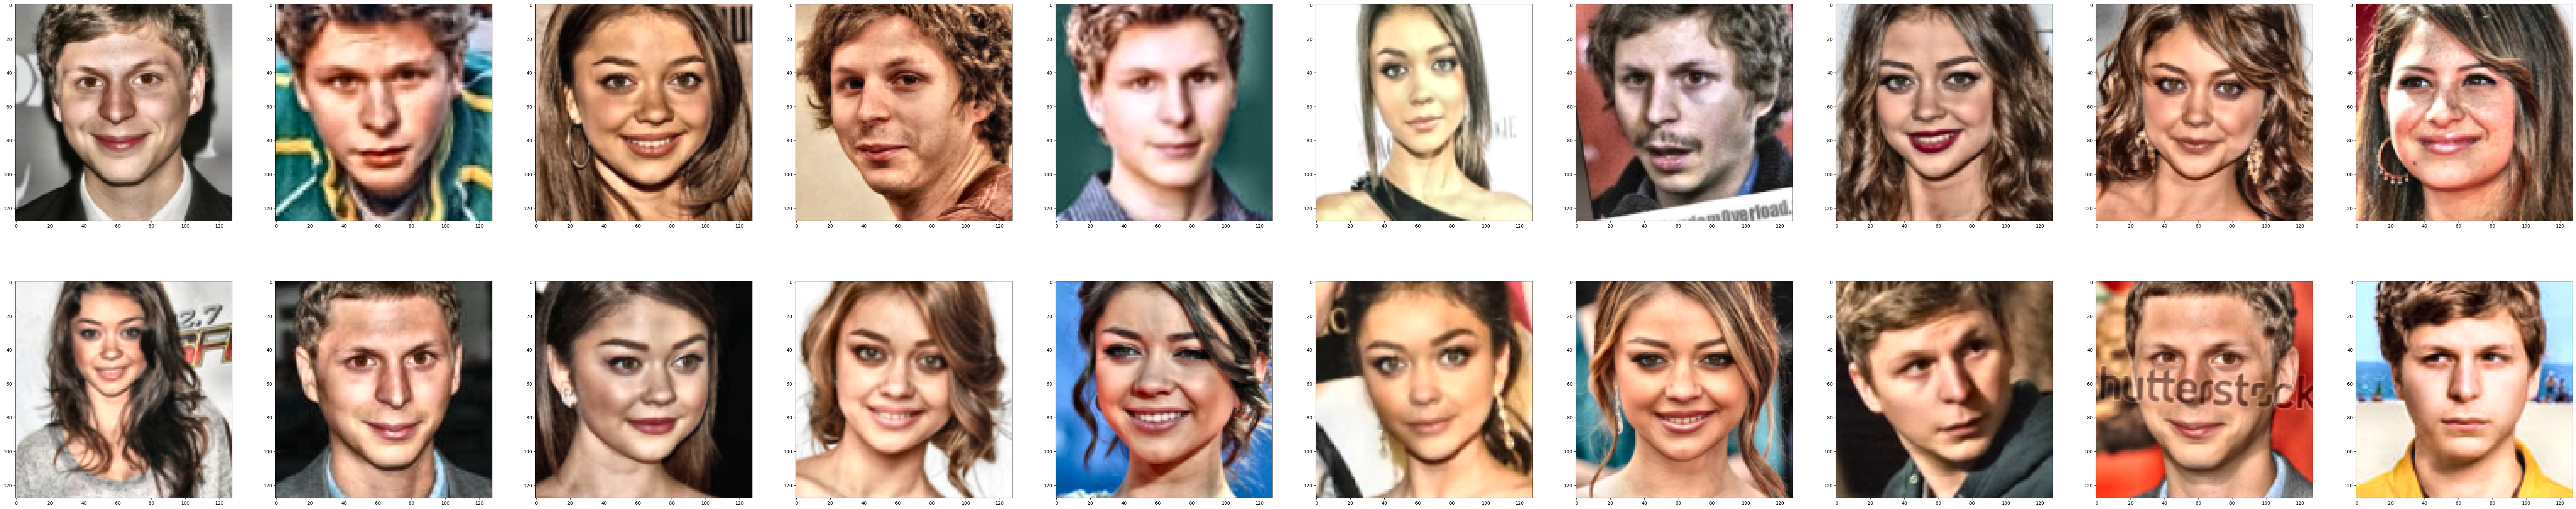

In [11]:
# plot faces of Michael and Sarah

plot_image_sequence(train_X[train_y == 0], n=20, imgs_per_row=10)

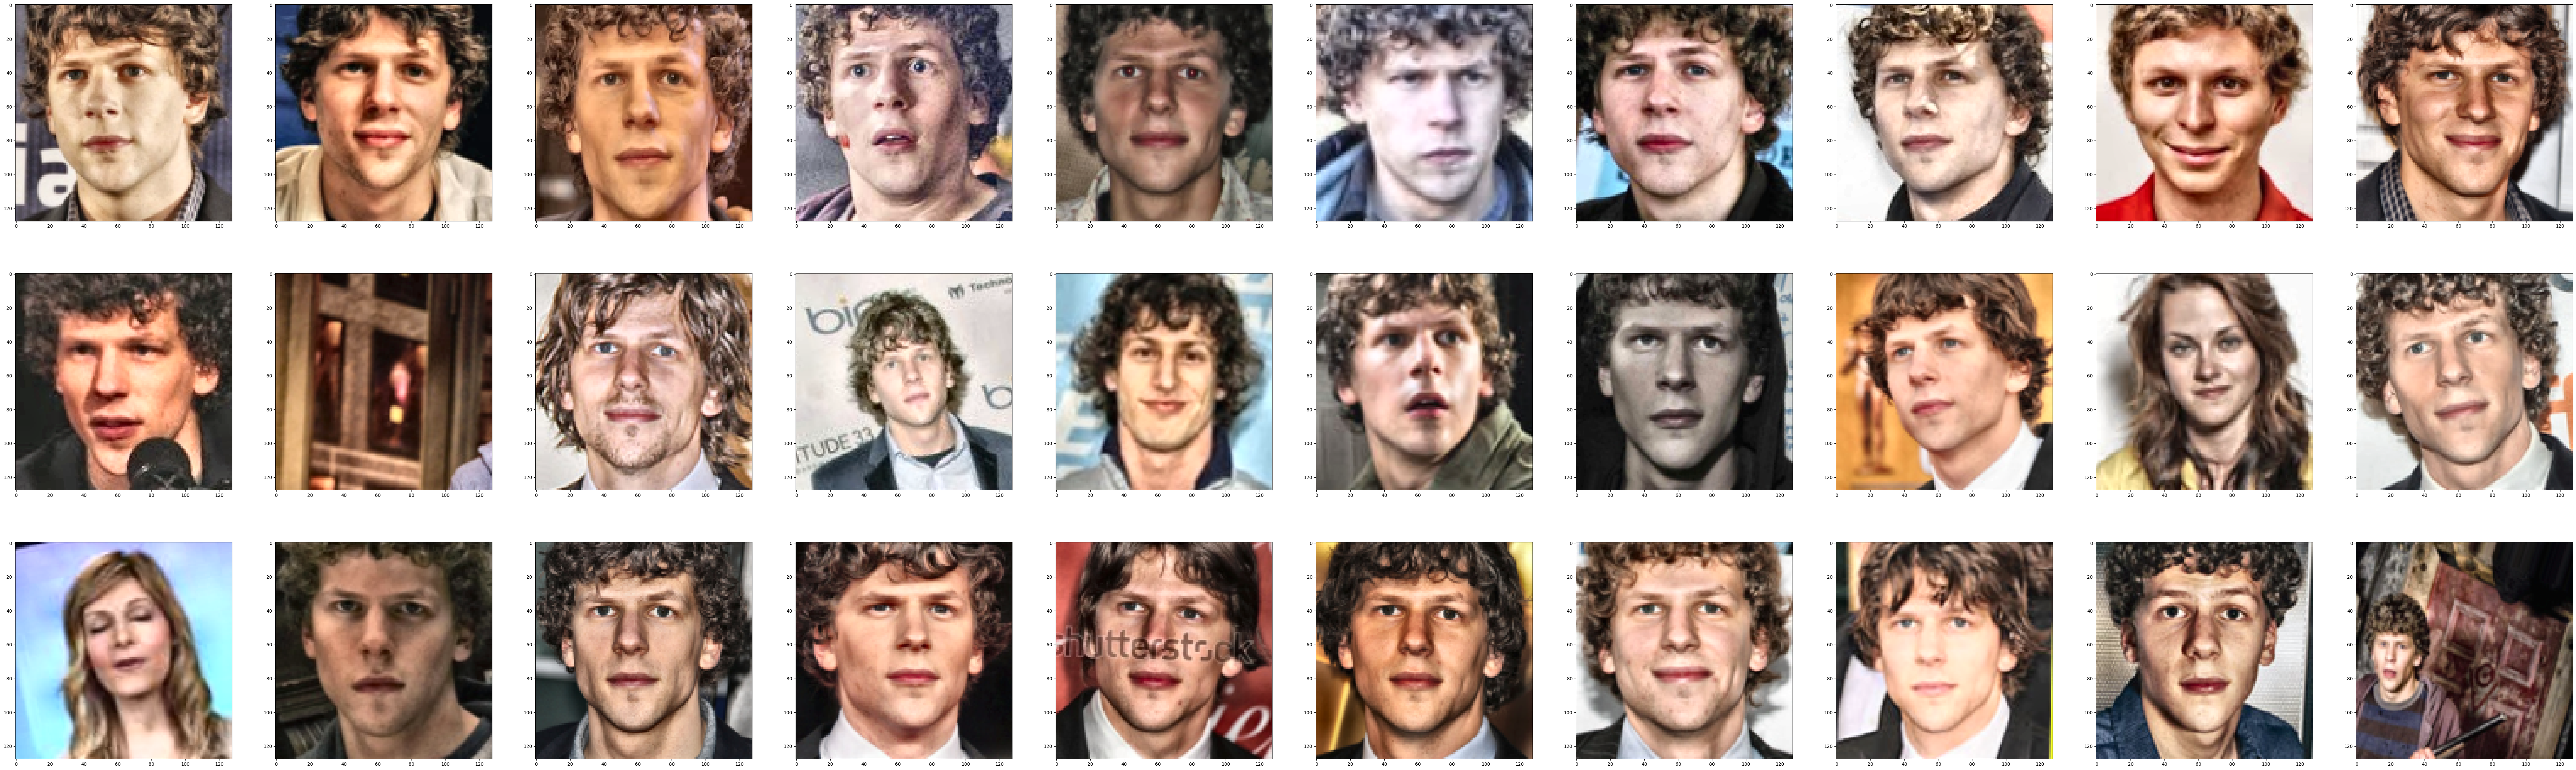

In [12]:
# plot faces of Jesse

plot_image_sequence(train_X[train_y == 1], n=30, imgs_per_row=10)

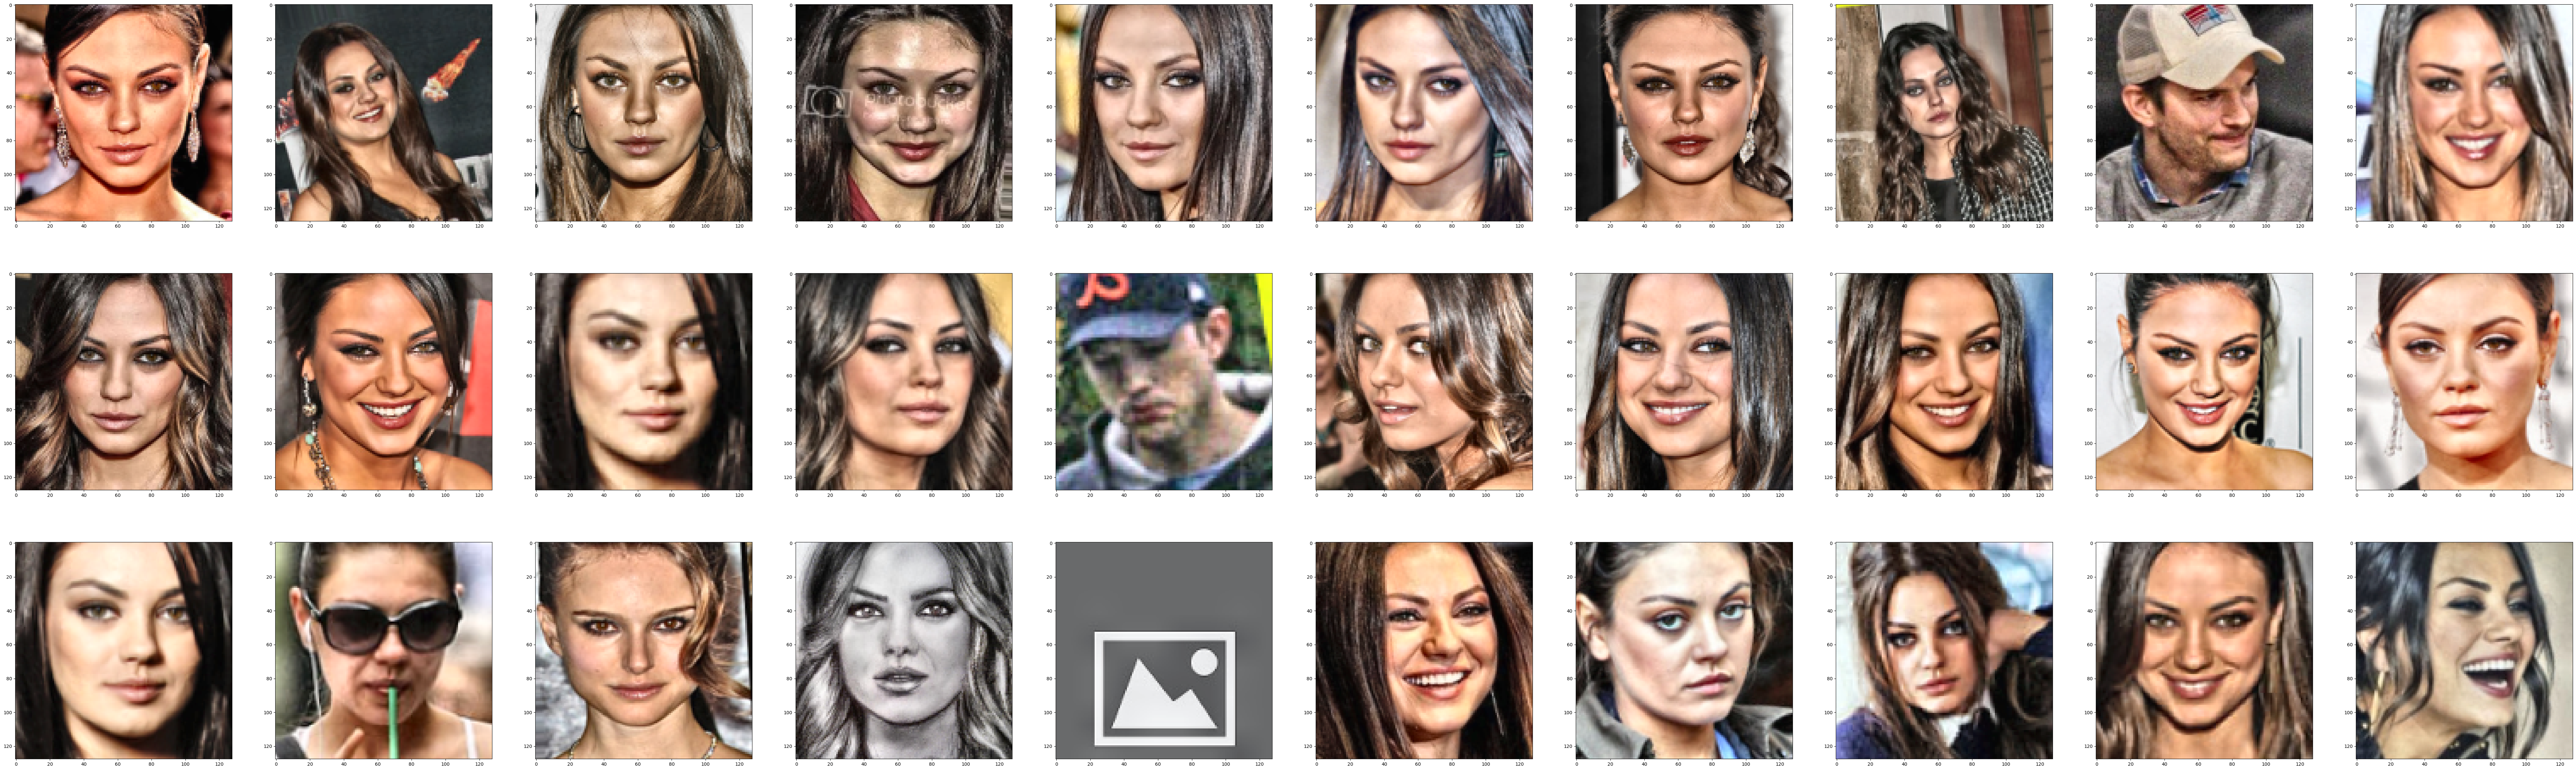

In [13]:
# plot faces of Mila

plot_image_sequence(train_X[train_y == 2], n=30, imgs_per_row=10)

## 0.4. Store Preprocessed data (optional)
<div class="alert alert-block alert-info">
<b>NOTE:</b> You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All". Feel free to use this to store intermediary results.
</div>

In [14]:
# save preprocessed data
prep_path = './kaggle/working/prepped_data/'
if not os.path.exists(prep_path):
    os.mkdir(prep_path)
    
np.save(os.path.join(prep_path, 'train_X.npy'), train_X)
np.save(os.path.join(prep_path, 'train_y.npy'), train_y)
np.save(os.path.join(prep_path, 'test_X.npy'), test_X)

# load preprocessed data
prep_path = './kaggle/working/prepped_data/'
if not os.path.exists(prep_path):
    os.mkdir(prep_path)
train_X = np.load(os.path.join(prep_path, 'train_X.npy'))
train_y = np.load(os.path.join(prep_path, 'train_y.npy'))
test_X = np.load(os.path.join(prep_path, 'test_X.npy'))

Now we are ready to rock!

# 1. Feature Representations
## 1.0. Example: Identify feature extractor
Our example feature extractor doesn't actually do anything... It just returns the input:
$$
\forall x : f(x) = x.
$$

It does make for a good placeholder and baseclass ;).

In [15]:
# ==========================================
# FEATURE EXTRACTOR CLASSES
# ==========================================
import cv2
import numpy as np
from sklearn.cluster import KMeans
from sklearn.svm import LinearSVC, SVC
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

class OptimizedHOG():
    def __init__(self, cell_size=(16, 16), block_size=(32, 32)):
        self.hog = cv2.HOGDescriptor(
            _winSize=(128, 128),
            _blockSize=block_size,
            _blockStride=cell_size,  
            _cellSize=cell_size,
            _nbins=9                 # ← Reverted from 12 to 9
        )
        
    def transform(self, images):
        features = []
        for img in images:
            gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY) if len(img.shape) == 3 else img
            # ── Gaussian blur to suppress JPEG/watermark noise ──
            gray = cv2.GaussianBlur(gray, (3, 3), 0)
            # Gamma correction
            gray = np.power(gray / 255.0, 0.5)
            gray = (gray * 255).astype(np.uint8)
            features.append(self.hog.compute(gray).flatten())
        return np.array(features)

class OptimizedSIFT():
    
    def __init__(self, n_clusters=50, step_size=8):
        self.sift = cv2.SIFT_create()
        self.n_clusters = n_clusters
        self.step_size = step_size
        self.kmeans = KMeans(n_clusters=self.n_clusters, random_state=42, n_init='auto')
        self.vocab_trained = False
        
    def _get_descriptors(self, images):
        desc_list = []
        for img in images:
            gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY) if len(img.shape) == 3 else img
            # NOTE: CLAHE already applied in preprocessor — don't double-apply!
            # ── Dense SIFT — keypoints on a regular grid ──
            kps = [cv2.KeyPoint(float(x), float(y), float(self.step_size)) 
                   for y in range(0, gray.shape[0], self.step_size)
                   for x in range(0, gray.shape[1], self.step_size)]
            _, des = self.sift.compute(gray, kps)
            desc_list.append(des if des is not None else np.zeros((1, 128), dtype=np.float32))
        return desc_list

    def fit_transform(self, images):
        self.train_desc = self._get_descriptors(images)
        all_desc = np.vstack(self.train_desc)
        self.kmeans.fit(all_desc)
        self.vocab_trained = True
        return self.transform(images, precomputed=self.train_desc)

    def transform(self, images, precomputed=None):
        descs = precomputed if precomputed else self._get_descriptors(images)
        features = np.zeros((len(images), self.n_clusters))
        for i, des in enumerate(descs):
            if not np.all(des == 0):
                words = self.kmeans.predict(des.astype(np.float32))
                for word in words:
                    features[i, word] += 1
        # ── L2 normalize each histogram for scale invariance ──
        norms = np.linalg.norm(features, axis=1, keepdims=True)
        norms[norms == 0] = 1
        features = features / norms
        return features

print("✅ Feature Extractor Classes Loaded Successfully!")

✅ Feature Extractor Classes Loaded Successfully!


## 1.1. Baseline 1: HOG feature extractor/Scale Invariant Feature Transform
...

In [16]:
# ==========================================
# COMPREHENSIVE HYPERPARAMETER GRID SEARCH 
# FOR HOG & SIFT
# ==========================================
from sklearn.svm import LinearSVC, SVC
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import time

print("--- Starting Automated Feature Optimization (v3) ---")
# Split validation set
X_t, X_v, y_t, y_v = train_test_split(train_X, train_y, test_size=0.2, random_state=42, stratify=train_y)

# ---------------------------------------------------------
# 1. OPTIMIZE HOG (128x128 images, nbins=9)
# ---------------------------------------------------------
print("\n🔍 Searching for best HOG configuration (v3: nbins=9, no double-CLAHE)...")
hog_grid = [
    {'name': 'Ultra-Fine', 'cell': (4, 4),   'block': (8, 8)},
    {'name': 'Fine',       'cell': (8, 8),   'block': (16, 16)},
    {'name': 'Medium-F',   'cell': (16, 16), 'block': (32, 32)},
    {'name': 'Medium-C',   'cell': (32, 32), 'block': (64, 64)},
    {'name': 'Coarse',     'cell': (64, 64), 'block': (128, 128)},
]

best_hog_score = 0
best_hog_config = None

for config in hog_grid:
    try:
        extractor = OptimizedHOG(cell_size=config['cell'], block_size=config['block'])
        train_feat = extractor.transform(X_t)
        val_feat = extractor.transform(X_v)
        
        scaler = StandardScaler()
        train_feat = scaler.fit_transform(train_feat)
        val_feat = scaler.transform(val_feat)
        
        clf = LinearSVC(random_state=42, class_weight='balanced', dual=False, max_iter=5000)
        clf.fit(train_feat, y_t)
        score = f1_score(y_v, clf.predict(val_feat), average='weighted')
        
        print(f"  Tested HOG {config['name']:<12} (Cell: {config['cell']}) -> F1: {score:.4f}")
        if score > best_hog_score:
            best_hog_score = score
            best_hog_config = config
    except Exception as e:
        print(f"  ⚠️ HOG {config['name']:<12} failed: {e}")

# ---------------------------------------------------------
# 2. OPTIMIZE SIFT (Dense SIFT + BoVW, expanded grid)
# ---------------------------------------------------------
print("\n🔍 Searching for best Dense SIFT configuration (v3: expanded K, RBF kernel)...")

cluster_sizes = [50, 100, 200, 300, 400]
step_sizes = [4, 6, 8, 16]

sift_grid = []
for k in cluster_sizes:
    for step in step_sizes:
        sift_grid.append({
            'clusters': k,
            'step_size': step,
            'name': f"K{k}-Step{step}"
        })

best_sift_score = 0
best_sift_config = None

for config in sift_grid:
    try:
        extractor = OptimizedSIFT(
            n_clusters=config['clusters'], 
            step_size=config['step_size']
        )
        
        train_feat = extractor.fit_transform(X_t)
        val_feat = extractor.transform(X_v)
        
        scaler = StandardScaler()
        train_feat = scaler.fit_transform(train_feat)
        val_feat = scaler.transform(val_feat)
        
        # V3: Use RBF kernel SVM — better for BoVW histograms
        clf = SVC(kernel='rbf', random_state=42, class_weight='balanced', gamma='scale')
        clf.fit(train_feat, y_t)
        score = f1_score(y_v, clf.predict(val_feat), average='weighted')
        
        print(f"  Tested SIFT {config['name']:<16} -> F1: {score:.4f}")
        if score > best_sift_score:
            best_sift_score = score
            best_sift_config = config
    except Exception as e:
        print(f"  ⚠️ SIFT {config['name']:<16} failed: {e}")

# ---------------------------------------------------------
# 3. RESULTS
# ---------------------------------------------------------
print("\n" + "="*45)
print("🏆 OPTIMIZATION COMPLETE (v3) 🏆")
print("="*45)
print(f"Best HOG:  {best_hog_config['name']} | Score: {best_hog_score:.4f}")
print(f"   -> Details: Cell {best_hog_config['cell']}, Block {best_hog_config['block']}")
print(f"Best SIFT: {best_sift_config['name']} | Score: {best_sift_score:.4f}")
print(f"   -> Details: Clusters {best_sift_config['clusters']}, Step {best_sift_config['step_size']}")
print("="*45)


--- Starting Automated Feature Optimization (v3) ---

🔍 Searching for best HOG configuration (v3: nbins=9, no double-CLAHE)...
  Tested HOG Ultra-Fine   (Cell: (4, 4)) -> F1: 0.5387
  Tested HOG Fine         (Cell: (8, 8)) -> F1: 0.6153
  Tested HOG Medium-F     (Cell: (16, 16)) -> F1: 0.6250
  Tested HOG Medium-C     (Cell: (32, 32)) -> F1: 0.6813
  Tested HOG Coarse       (Cell: (64, 64)) -> F1: 0.4350

🔍 Searching for best Dense SIFT configuration (v3: expanded K, RBF kernel)...
  Tested SIFT K50-Step4        -> F1: 0.5530
  Tested SIFT K50-Step6        -> F1: 0.6180
  Tested SIFT K50-Step8        -> F1: 0.6250
  Tested SIFT K50-Step16       -> F1: 0.5476
  Tested SIFT K100-Step4       -> F1: 0.5474
  Tested SIFT K100-Step6       -> F1: 0.6236
  Tested SIFT K100-Step8       -> F1: 0.6101
  Tested SIFT K100-Step16      -> F1: 0.6859
  Tested SIFT K200-Step4       -> F1: 0.5657
  Tested SIFT K200-Step6       -> F1: 0.6813
  Tested SIFT K200-Step8       -> F1: 0.7470
  Tested SIFT K200

In [17]:
# ==========================================
# FINAL EXTRACTION & EXPORT
# ==========================================
from sklearn.preprocessing import StandardScaler
import numpy as np

print(f"1. Extracting final HOG features using {best_hog_config['name']} parameters...")
final_hog = OptimizedHOG(
    cell_size=best_hog_config['cell'], 
    block_size=best_hog_config['block']
)
hog_train_full = final_hog.transform(train_X)
hog_test_full = final_hog.transform(test_X)

print(f"2. Extracting final Dense SIFT features using {best_sift_config['name']} parameters...")
final_sift = OptimizedSIFT(
    n_clusters=best_sift_config['clusters'], 
    step_size=best_sift_config['step_size']
)
sift_train_full = final_sift.fit_transform(train_X)
sift_test_full = final_sift.transform(test_X)

print("3. Standardizing features...")
scaler_hog = StandardScaler()
hog_train_scaled = scaler_hog.fit_transform(hog_train_full)
hog_test_scaled = scaler_hog.transform(hog_test_full)

scaler_sift = StandardScaler()
sift_train_scaled = scaler_sift.fit_transform(sift_train_full)
sift_test_scaled = scaler_sift.transform(sift_test_full)

print("4. Saving to 'group16_features.npz'...")
np.savez_compressed(
    'group16_features.npz', 
    hog_train=hog_train_scaled, 
    hog_test=hog_test_scaled, 
    sift_train=sift_train_scaled, 
    sift_test=sift_test_scaled,
    train_y=train_y
)

print("\n✅ DONE! All optimized features extracted, scaled, and saved.")


1. Extracting final HOG features using Medium-C parameters...
2. Extracting final Dense SIFT features using K200-Step8 parameters...
3. Standardizing features...
4. Saving to 'group16_features.npz'...

✅ DONE! All optimized features extracted, scaled, and saved.


Running t-SNE on optimized HOG features...
Running t-SNE on optimized SIFT features...


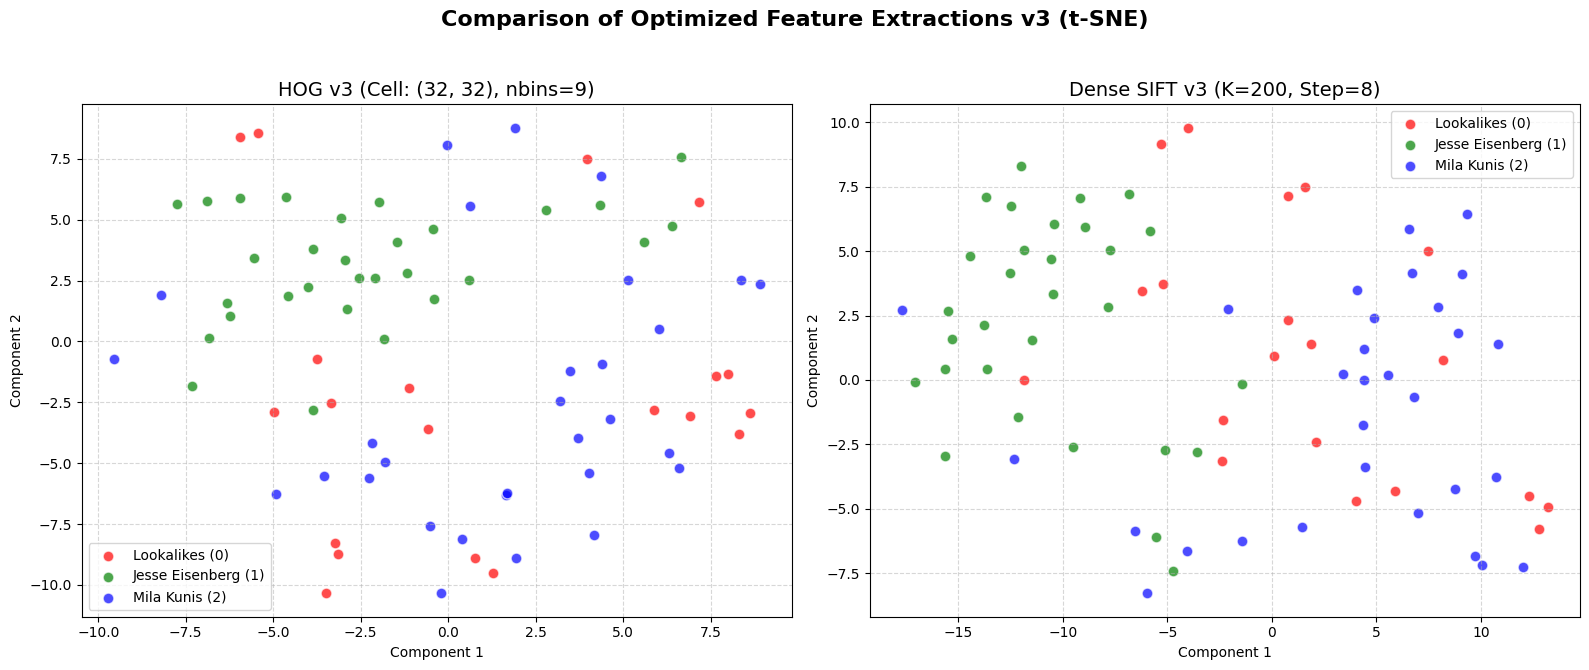

In [18]:
# ==========================================
# Visualize HOG/SIFT Features using t-SNE
# ==========================================
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

print("Running t-SNE on optimized HOG features...")
tsne_hog = TSNE(n_components=2, random_state=42, init='pca', learning_rate='auto', perplexity=15)
hog_2d = tsne_hog.fit_transform(hog_train_scaled)

print("Running t-SNE on optimized SIFT features...")
tsne_sift = TSNE(n_components=2, random_state=42, init='pca', learning_rate='auto', perplexity=15)
sift_2d = tsne_sift.fit_transform(sift_train_scaled)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Comparison of Optimized Feature Extractions v3 (t-SNE)', fontsize=16, fontweight='bold')

colors = ['red', 'green', 'blue']
labels = ['Lookalikes (0)', 'Jesse Eisenberg (1)', 'Mila Kunis (2)']

# --- Plot 1: HOG ---
for class_idx in range(3):
    idx = train_y == class_idx
    axes[0].scatter(
        hog_2d[idx, 0], hog_2d[idx, 1], 
        c=colors[class_idx], label=labels[class_idx], 
        alpha=0.7, edgecolors='w', s=60
    )
axes[0].set_title(f"HOG v3 (Cell: {best_hog_config['cell']}, nbins=9)", fontsize=14)
axes[0].set_xlabel('Component 1')
axes[0].set_ylabel('Component 2')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.5)

# --- Plot 2: SIFT ---
for class_idx in range(3):
    idx = train_y == class_idx
    axes[1].scatter(
        sift_2d[idx, 0], sift_2d[idx, 1], 
        c=colors[class_idx], label=labels[class_idx], 
        alpha=0.7, edgecolors='w', s=60
    )
axes[1].set_title(f"Dense SIFT v3 (K={best_sift_config['clusters']}, Step={best_sift_config['step_size']})", fontsize=14)
axes[1].set_xlabel('Component 1')
axes[1].set_ylabel('Component 2')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


### 1.1.2. Discussion
...
preprocessing: 
we tested couple data preprocessing method including HAARP and Mediapipe.


HOG vs SIFT:



## 1.2. Baseline 2: PCA feature extractor
...

In [19]:
# ==========================================
# PCA FEATURE EXTRACTOR
# ==========================================
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.decomposition import PCA
import numpy as np
import cv2

# Inheriting from BaseEstimator and TransformerMixin makes it officially compatible with scikit-learn!
class EigenfaceExtractor(BaseEstimator, TransformerMixin):
    """Learns features directly from image data using Principal Component Analysis."""
    
    def __init__(self, max_components=100):
        self.max_components = max_components
        self.is_fit = False
        self.pca = None 
        
    def _preprocess(self, images):
        """Converts images to grayscale and flattens them to 1D arrays."""
        processed = []
        for img in images:
            gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY) if len(img.shape) == 3 else img
            processed.append(gray.flatten())
        return np.array(processed)
        
    # FIX 1: Add a standard fit method that returns 'self'
    def fit(self, images, y=None):
        self.fit_transform(images, y)
        return self

    # FIX 2: Add y=None to catch the labels passed by the Pipeline
    def fit_transform(self, images, y=None):
        X = self._preprocess(images)
        
        n_samples = X.shape[0]
        actual_components = min(self.max_components, n_samples)
        
        self.pca = PCA(n_components=actual_components, whiten=True, random_state=42)
        features = self.pca.fit_transform(X)
        self.is_fit = True
        return features
        
    # FIX 3: Add y=None here as well
    def transform(self, images, y=None):
        if not self.is_fit:
            raise ValueError("You must call fit_transform on train_X first!")
        X = self._preprocess(images)
        return self.pca.transform(X)

In [20]:
# ==========================================
# OPTIMIZE & EVALUATE PCA
# ==========================================
from sklearn.svm import SVC
from sklearn.metrics import f1_score, classification_report
from sklearn.model_selection import train_test_split

print("--- Starting PCA Performance Evaluation ---")

# Split raw images for validation
X_t_img, X_v_img, y_t, y_v = train_test_split(
    train_X, train_y, test_size=0.2, random_state=42, stratify=train_y
)

# Test keeping different numbers of Eigenfaces
pca_configs = [10, 20, 30, 40, 60, 80] 
best_pca_score = 0
best_pca_config = None
best_pca_clf = None
best_pca_val_feat = None

for n_comp in pca_configs:
    # 1. Initialize and Extract
    extractor = EigenfaceExtractor(max_components=n_comp)
    train_feat = extractor.fit_transform(X_t_img)
    val_feat = extractor.transform(X_v_img)
    
    # 2. Train an SVM 
    # Note: We use an 'rbf' kernel here because PCA features are highly non-linear!
    clf = SVC(kernel='rbf', class_weight='balanced', random_state=42)
    clf.fit(train_feat, y_t)
    
    # 3. Evaluate
    preds = clf.predict(val_feat)
    score = f1_score(y_v, preds, average='weighted')
    
    print(f"Tested PCA [Components: {train_feat.shape[1]:<2}] -> Val F1-Score: {score:.4f}")
    
    if score > best_pca_score:
        best_pca_score = score
        best_pca_config = train_feat.shape[1]
        best_pca_clf = clf
        best_pca_val_feat = val_feat

print("\n" + "="*40)
print(f"🏆 BEST PCA FOUND: {best_pca_config} Components (Score: {best_pca_score:.4f})")
print("="*40)

# Let's print the detailed report for the winning PCA model
print("\nDetailed Performance of Best PCA:")
target_names = ['Lookalikes (0)', 'Jesse (1)', 'Mila (2)']
print(classification_report(y_v, best_pca_clf.predict(best_pca_val_feat), target_names=target_names))

# Re-extract the BEST PCA on the full dataset
final_pca = EigenfaceExtractor(max_components=best_pca_config)
pca_train_full = final_pca.fit_transform(train_X)
pca_test_full = final_pca.transform(test_X)

# Save it alongside HOG and SIFT
np.savez_compressed(
    'group16_features.npz', 
    hog_train=hog_train_scaled, 
    hog_test=hog_test_scaled, 
    sift_train=sift_train_scaled, 
    sift_test=sift_test_scaled,
    pca_train=pca_train_full,    # <-- Added PCA!
    pca_test=pca_test_full,      # <-- Added PCA!
    train_y=train_y
)

--- Starting PCA Performance Evaluation ---
Tested PCA [Components: 10] -> Val F1-Score: 0.4615
Tested PCA [Components: 20] -> Val F1-Score: 0.4873
Tested PCA [Components: 30] -> Val F1-Score: 0.4067
Tested PCA [Components: 40] -> Val F1-Score: 0.4616
Tested PCA [Components: 60] -> Val F1-Score: 0.6548
Tested PCA [Components: 64] -> Val F1-Score: 0.2045

🏆 BEST PCA FOUND: 60 Components (Score: 0.6548)

Detailed Performance of Best PCA:
                precision    recall  f1-score   support

Lookalikes (0)       0.50      0.25      0.33         4
     Jesse (1)       0.75      1.00      0.86         6
      Mila (2)       0.67      0.67      0.67         6

      accuracy                           0.69        16
     macro avg       0.64      0.64      0.62        16
  weighted avg       0.66      0.69      0.65        16



### 1.2.1. Eigenface Plots
...

Explained variance (top 12): 58.67%


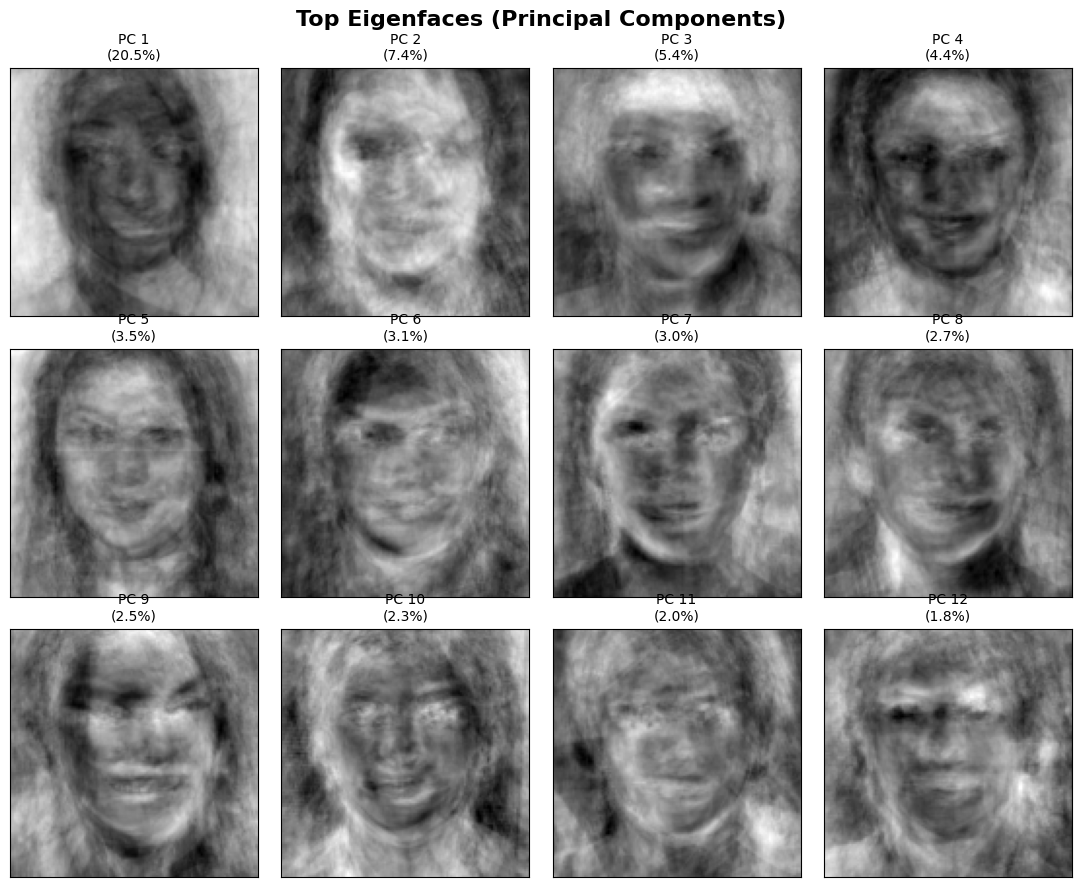

In [21]:
# ==========================================
# PLOT THE EIGENFACES FROM TRAINED PIPELINE
# ==========================================
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
# --- STEP 1: Flatten images to 1D vectors ---
n_samples = len(train_X)
h, w = 128, 128  # FACE_SIZE
# Convert to grayscale and flatten
X_gray = np.array([cv2.cvtColor(img, cv2.COLOR_RGB2GRAY) for img in train_X])
X_flat = X_gray.reshape(n_samples, h * w).astype(np.float64)
# --- STEP 2: Fit PCA ---
n_components = 12  # number of eigenfaces to show
pca = PCA(n_components=n_components, whiten=True, random_state=42)
pca.fit(X_flat)
print(f"Explained variance (top {n_components}): {pca.explained_variance_ratio_.sum():.2%}")
# --- STEP 3: Plot Eigenfaces ---
eigenfaces = pca.components_.reshape((n_components, h, w))
fig, axes = plt.subplots(3, 4, figsize=(11, 9))
fig.suptitle("Top Eigenfaces (Principal Components)", fontsize=16, fontweight='bold')
for i, ax in enumerate(axes.flat):
    if i < n_components:
        ax.imshow(eigenfaces[i], cmap='gray')
        ax.set_title(f"PC {i+1}\n({pca.explained_variance_ratio_[i]:.1%})", size=10)
    ax.set_xticks([])
    ax.set_yticks([])
plt.tight_layout()
plt.show()

### 1.2.2. Feature Space Plots
...

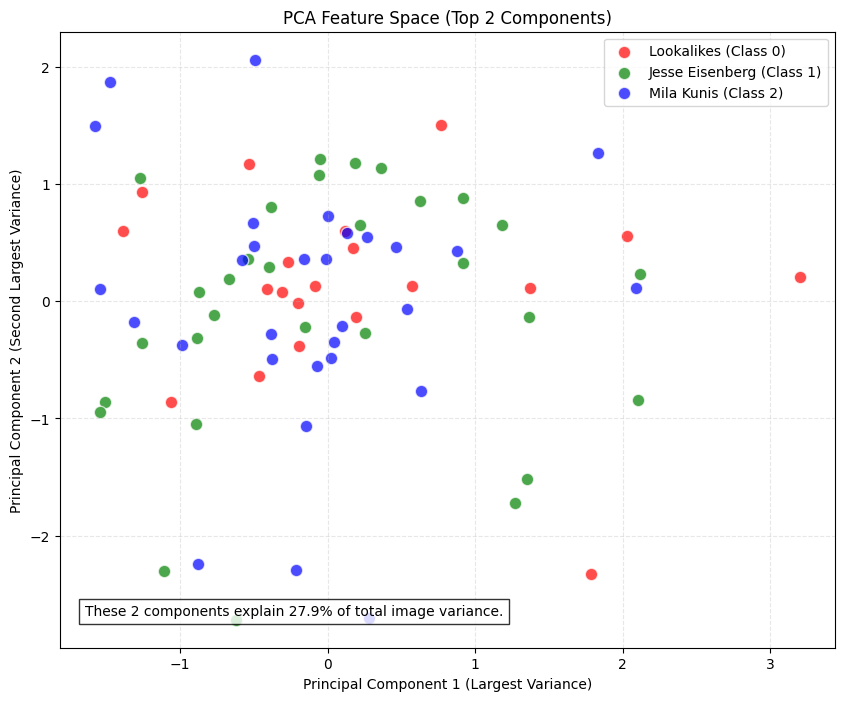

In [22]:
# ==========================================
# PCA FEATURE SPACE SCATTER PLOT
# ==========================================
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
# 1. Flatten grayscale images
X_gray = np.array([cv2.cvtColor(img, cv2.COLOR_RGB2GRAY) for img in train_X])
X_flat = X_gray.reshape(len(train_X), -1).astype(np.float64)
# 2. Fit PCA and transform
pca = PCA(n_components=min(50, len(X_flat)), whiten=True, random_state=42)
pca_features = pca.fit_transform(X_flat)
# 3. Plot PC1 vs PC2
plt.figure(figsize=(10, 8))
colors = ['red', 'green', 'blue']
labels = ['Lookalikes (Class 0)', 'Jesse Eisenberg (Class 1)', 'Mila Kunis (Class 2)']
for class_idx in range(3):
    idx = (train_y == class_idx)
    plt.scatter(
        pca_features[idx, 0], pca_features[idx, 1],
        c=colors[class_idx], label=labels[class_idx],
        alpha=0.7, edgecolors='w', s=80
    )
plt.title('PCA Feature Space (Top 2 Components)')
plt.xlabel('Principal Component 1 (Largest Variance)')
plt.ylabel('Principal Component 2 (Second Largest Variance)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
total_var_2d = (pca.explained_variance_ratio_[0] + pca.explained_variance_ratio_[1]) * 100
plt.figtext(0.15, 0.15,
            f"These 2 components explain {total_var_2d:.1f}% of total image variance.",
            fontsize=10, bbox=dict(facecolor='white', alpha=0.8))
plt.show()

### 1.2.3. Discussion
...

# 2. Evaluation Metrics
## 2.0. Example: Accuracy
As example metric we take the accuracy. Informally, accuracy is the proportion of correct predictions over the total amount of predictions. It is used a lot in classification but it certainly has its disadvantages...

In [23]:
from sklearn.metrics import accuracy_score
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import numpy as np
# 1. Build a PCA + SVM pipeline from scratch
X_gray = np.array([cv2.cvtColor(img, cv2.COLOR_RGB2GRAY) for img in train_X])
X_flat = X_gray.reshape(len(train_X), -1).astype(np.float64)
model = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=50, whiten=True, random_state=42)),
    ('svm', SVC(kernel='rbf', C=10, class_weight='balanced', probability=True))
])
# 2. Train and predict
model.fit(X_flat, train_y)
train_y_star = model.predict(X_flat)
# 3. Accuracy
print("Accuracy on the training set: {:.2f}".format(accuracy_score(train_y, train_y_star)))

Accuracy on the training set: 1.00


# 3. Classifiers
## 3.0. Example: The *'not so smart'* classifier
This random classifier is not very complicated. It makes predictions at random, based on the distribution obseved in the training set. **It thus assumes** that the class labels of the test set will be distributed similarly to the training set.

In [24]:
class RandomClassificationModel:
    """Random classifier, draws a random sample based on class distribution observed 
    during training."""
    
    def fit(self, X, y):
        """Adjusts the class ratio instance variable to the one observed in y. 

        Parameters
        ----------
        X : tensor
            Training set
        y : array
            Training set labels

        Returns
        -------
        self : RandomClassificationModel
        """
        
        self.classes, self.class_ratio = np.unique(y, return_counts=True)
        self.class_ratio = self.class_ratio / self.class_ratio.sum()
        return self
        
    def predict(self, X):
        """Samples labels for the input data. 

        Parameters
        ----------
        X : tensor
            dataset
            
        Returns
        -------
        y_star : array
            'Predicted' labels
        """

        np.random.seed(0)
        return np.random.choice(self.classes, size = X.shape[0], p=self.class_ratio)
    
    def __call__(self, X):
        return self.predict(X)
    

## 3.1. Baseline 1: My favorite classifier
...

In [25]:
# ==========================================
# BASELINE 1: MY FAVORITE CLASSIFIER
# ==========================================
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, f1_score
import numpy as np

class FavoriteClassificationModel:
    """
    An optimized Support Vector Machine (SVM) classifier.
    Automatically searches for the best C and gamma hyperparameters using cross-validation.
    """
    def __init__(self):
        self.best_model = None
        self.best_params = None
        self.best_score = 0
        
    def fit(self, X, y):
        print("Starting Grid Search for SVM Hyperparameters...")
        
        # Define the parameter grid for an RBF Kernel
        # class_weight='balanced' is CRUCIAL here because you have many Lookalikes (Class 0) 
        # but fewer images of Jesse and Mila.
        param_grid = {
            'C': [0.1, 1, 10, 100],
            'gamma': [0.001, 0.01, 0.1, 1, 'scale'],
            'class_weight': ['balanced'] 
        }
        
        # Initialize GridSearch with 5-fold cross-validation
        # n_jobs=-1 tells Kaggle to use all available CPU cores to run this 4x faster!
        grid_search = GridSearchCV(
            SVC(kernel='rbf', random_state=42), 
            param_grid, 
            cv=5, 
            scoring='f1_weighted', 
            n_jobs=-1, 
            verbose=1
        )
        
        # Fit the model to find the best parameters
        grid_search.fit(X, y)
        
        # Save the winning model
        self.best_model = grid_search.best_estimator_
        self.best_params = grid_search.best_params_
        self.best_score = grid_search.best_score_
        
        print("\n✅ Training Complete!")
        print(f"Best Parameters: {self.best_params}")
        print(f"Best Cross-Validation F1-Score: {self.best_score:.4f}")
        
        return self

    def __call__(self, X):
        """Predicts labels for the input data."""
        if self.best_model is None:
            raise ValueError("Model has not been trained. Call .fit() first.")
        return self.best_model.predict(X)

In [26]:
# ==========================================
# TRAIN & EVALUATE THE FAVORITE CLASSIFIER
# ==========================================
from sklearn.model_selection import train_test_split

print("1. Loading optimized features from Part 1...")
data = np.load('group16_features.npz')

# Choose your best feature set here! (hog_train, sift_train, or pca_train)
X_train_full = data['hog_train']  
y_train_full = data['train_y']

# Split a quick validation set to see the final Confusion Matrix/Report
X_t, X_v, y_t, y_v = train_test_split(X_train_full, y_train_full, test_size=0.2, random_state=42, stratify=y_train_full)

# 2. Instantiate and fit the model
favorite_model = FavoriteClassificationModel()
favorite_model.fit(X_t, y_t)

# 3. Final Validation Evaluation
print("\n--- Final Model Performance on Validation Set ---")
val_predictions = favorite_model(X_v)

target_names = ['Lookalikes (0)', 'Jesse (1)', 'Mila (2)']
print(classification_report(y_v, val_predictions, target_names=target_names))

# 4. Retrain on 100% of the data for the final Kaggle Submission
print("\nRetraining the absolute best model on 100% of training data for Kaggle submission...")
final_kaggle_model = FavoriteClassificationModel()
final_kaggle_model.fit(X_train_full, y_train_full)

1. Loading optimized features from Part 1...
Starting Grid Search for SVM Hyperparameters...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

✅ Training Complete!
Best Parameters: {'C': 10, 'class_weight': 'balanced', 'gamma': 0.001}
Best Cross-Validation F1-Score: 0.7780

--- Final Model Performance on Validation Set ---
                precision    recall  f1-score   support

Lookalikes (0)       0.75      0.75      0.75         4
     Jesse (1)       0.80      0.67      0.73         6
      Mila (2)       0.71      0.83      0.77         6

      accuracy                           0.75        16
     macro avg       0.75      0.75      0.75        16
  weighted avg       0.76      0.75      0.75        16


Retraining the absolute best model on 100% of training data for Kaggle submission...
Starting Grid Search for SVM Hyperparameters...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

✅ Training Complete!
Best Parameters: {'C': 1, 'class_weight': 'balanc

# 4. Experiments
<div class="alert alert-block alert-info"> <b>NOTE:</b> Do <i>NOT</i> use this section to keep track of every little change you make in your code! Instead, highlight the most important findings and the major (best) pipelines that you've discovered.  
</div>
<br>

## 4.0. Example: basic pipeline
The basic pipeline takes any input and samples a label based on the class label distribution of the training set. As expected the performance is very poor, predicting approximately 1/4 correctly on the training set. There is a lot of room for improvement but this is left to you ;). 

In [27]:
# ==========================================
# 4.0 EXAMPLE: BASIC PIPELINE
# ==========================================
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

class FullVisionPipeline:
    """
    An end-to-end pipeline that takes RAW images, extracts features, 
    scales them, and makes a final classification prediction.
    """
    def __init__(self, feature_extractor, classifier):
        # We build a scikit-learn pipeline with 3 sequential steps
        self.pipeline = Pipeline([
            ('extractor', feature_extractor),     # Step 1: HOG, SIFT, or PCA
            ('scaler', StandardScaler()),         # Step 2: Normalize the numbers
            ('classifier', classifier)            # Step 3: Your Favorite SVM
        ])
        
    def fit(self, X_raw, y):
        """Trains the entire pipeline from start to finish."""
        print("Training the end-to-end pipeline...")
        self.pipeline.fit(X_raw, y)
        print("Pipeline trained successfully!")
        return self
        
    def predict(self, X_raw):
        """Takes raw images and outputs the final label guesses."""
        return self.pipeline.predict(X_raw)

# ---------------------------------------------------------
# HOW TO USE IT (Example with your Best PCA and Best SVM)
# ---------------------------------------------------------

# 1. Initialize your winning feature extractor from Part 1
# (You can swap this with your OptimizedHOG or OptimizedSIFT)
best_extractor = EigenfaceExtractor(max_components=best_pca_config)

# 2. Initialize your winning classifier from Part 2
# (Using the best parameters found by your GridSearch)
best_classifier = SVC(
    kernel='rbf', 
    C=10,             # Replace with your actual best C
    gamma='scale',    # Replace with your actual best gamma
    class_weight='balanced',
    random_state=42
)

# 3. Create the unified pipeline
my_basic_pipeline = FullVisionPipeline(
    feature_extractor=best_extractor, 
    classifier=best_classifier
)

# 4. Train it directly on the RAW training images!
# Notice we are passing train_X (the images), NOT the .npz features!
my_basic_pipeline.fit(train_X, train_y)

# 5. Predict directly on the RAW test images!
test_predictions = my_basic_pipeline.predict(test_X)


Training the end-to-end pipeline...
Pipeline trained successfully!


In [28]:
feature_extractor = IdentityFeatureExtractor() 
classifier = RandomClassificationModel()

# train the model on the features
classifier.fit(feature_extractor(train_X), train_y)

# model/final pipeline
model = lambda X: classifier(feature_extractor(X))

NameError: name 'IdentityFeatureExtractor' is not defined

In [ ]:
# evaluate performance of the model on the training set
train_y_star = model(train_X)

"The performance on the training set is {:.2f}. This however, does not tell us much about the actual performance (generalisability).".format(
    accuracy_score(train_y, train_y_star))

In [ ]:
# predict the labels for the test set 
test_y_star = model(test_X)

# 5. Publishing best results

In [ ]:
# 1. Generate final predictions using the pipeline
# This automatically extracts features from test_X and classifies them
test_y_star = my_basic_pipeline.predict(test_X)

# 2. Prepare the submission dataframe
# Assuming 'test' is the original dataframe containing image info
submission = test.copy().drop('img', axis=1)
submission['class'] = test_y_star

# 3. Save to CSV for Kaggle upload
submission.to_csv('submission.csv', index=True)
print("✅ Final submission.csv created!")
submission.head()

In [ ]:
submission.to_csv('submission.csv')

# 6. Discussion
...

In summary we contributed the following: 
* 
